In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub as kh
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

%matplotlib inline

In [67]:
EXAMPLE_DATASET = {
    "dataset": "aakash50897/churn-modellingcsv",
    "file": "Churn_Modelling.csv"
}

TARGET_DATASET = EXAMPLE_DATASET

In [68]:
DATASET = TARGET_DATASET["dataset"]
DOWNLOAD_PATH = f"data/{TARGET_DATASET['dataset']}"
DATASET_FILE = TARGET_DATASET["file"]
TEST_SIZE = 0.2
RANDOM_STATE = 42

In [69]:
df_path = kh.dataset_download(DATASET, output_dir=DOWNLOAD_PATH)
df = pd.read_csv(f"{df_path}/{DATASET_FILE}")
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [70]:
le = LabelEncoder()

In [71]:
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

/var/folders/8s/hnrlcfv16rdb1gwgppl6tj1c0000gn/T/ipykernel_45660/2386425612.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [72]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [73]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

In [75]:
scaler = StandardScaler()

In [76]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [77]:
model = Sequential()

In [78]:
model.add(Dense(units=10, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(units=10, activation="relu"))
model.add(Dense(units=1, activation="sigmoid"))

/Users/ccatlabuga/Documents/Personal/RNIP/lab1/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [79]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231 (924.00 B)

 Trainable params: 231 (924.00 B)

 Non-trainable params: 0 (0.00 B)

In [80]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [81]:
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 850us/step - accuracy: 0.7785 - loss: 0.5354 - val_accuracy: 0.8090 - val_loss: 0.4648
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - accuracy: 0.8119 - loss: 0.4545 - val_accuracy: 0.8245 - val_loss: 0.4268
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step - accuracy: 0.8249 - loss: 0.4297 - val_accuracy: 0.8305 - val_loss: 0.4105
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.8281 - loss: 0.4182 - val_accuracy: 0.8360 - val_loss: 0.4025
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step - accuracy: 0.8280 - loss: 0.4114 - val_accuracy: 0.8350 - val_loss: 0.3970
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step - accuracy: 0.8282 - loss: 0.4069 - val_accuracy: 0.8380 - val_loss: 0.3946
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step - accuracy: 0.8299 - loss: 0.4029 - val_accuracy: 0.8395 - val_loss: 0.3892
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step - accuracy: 0.8306 - loss: 0.3995 - 

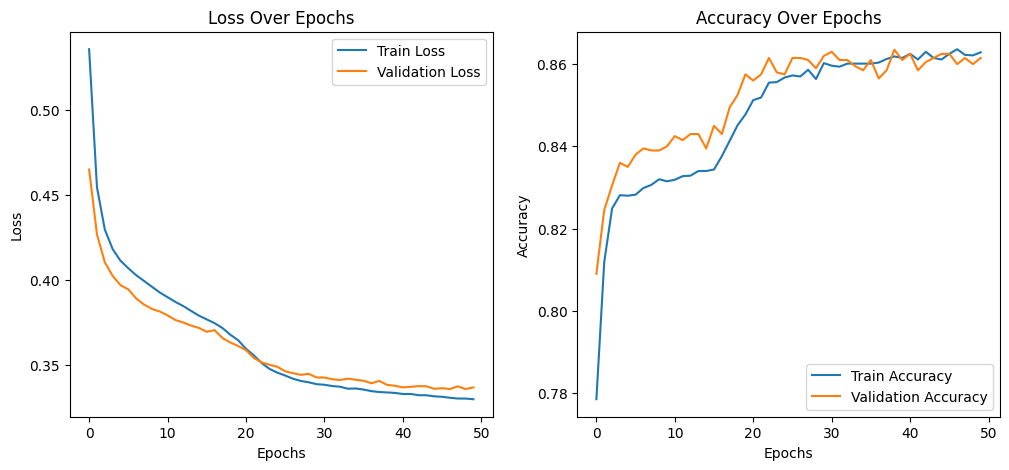

In [82]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [83]:
predictions = (model.predict(X_test) > 0.5).astype("int32")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step


In [84]:
print("\n--- Evaluation Metrics ---")
print("Accuracy Score:", accuracy_score(y_test, predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))


--- Evaluation Metrics ---
Accuracy Score: 0.8615

Confusion Matrix:
 [[1529   78]
 [ 199  194]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.92      1607
           1       0.71      0.49      0.58       393

    accuracy                           0.86      2000
   macro avg       0.80      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [85]:
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights_dict)


Class Weights: {0: np.float64(0.6293266205160478), 1: np.float64(2.4330900243309004)}


In [86]:
optimized_model = Sequential()

In [87]:
optimized_model.add(BatchNormalization(input_shape=(X_train.shape[1],)))

optimized_model.add(Dense(units=128, activation="relu"))
optimized_model.add(Dropout(0.2))
optimized_model.add(BatchNormalization())

optimized_model.add(Dense(units=64, activation="relu"))
optimized_model.add(Dropout(0.2))
optimized_model.add(BatchNormalization())

optimized_model.add(Dense(units=32, activation="relu"))
optimized_model.add(Dense(units=1, activation="sigmoid"))

/Users/ccatlabuga/Documents/Personal/RNIP/lab1/venv/lib/python3.13/site-packages/keras/src/layers/normalization/batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [88]:
optimized_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_10          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,585 (49.16 KB)

 Trainable params: 12,181 (47.58 KB)

 Non-trainable params: 404 (1.58 KB)

In [89]:
optimized_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [90]:
optimized_model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), class_weight=class_weights_dict)

Epoch 1/50


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6426 - loss: 0.6063 - val_accuracy: 0.7655 - val_loss: 0.4967
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7132 - loss: 0.5388 - val_accuracy: 0.7490 - val_loss: 0.4775
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7386 - loss: 0.5144 - val_accuracy: 0.7615 - val_loss: 0.4650
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - accuracy: 0.7433 - loss: 0.5068 - val_accuracy: 0.7525 - val_loss: 0.4869
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7586 - loss: 0.4956 - val_accuracy: 0.7765 - val_loss: 0.4548
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7565 - loss: 0.4907 - val_accuracy: 0.7730 - val_loss: 0.4673
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7594 - loss: 0.4929 - val_accuracy: 0.7910 - val_loss: 0.4500
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7564 - loss: 0.4879 - val_accuracy: 0.8170 - va

In [91]:
optimized_predictions = (optimized_model.predict(X_test) > 0.5).astype("int32")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step


In [92]:
print("\n--- Optimized Evaluation Metrics ---")
print("Accuracy Score:", accuracy_score(y_test, optimized_predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, optimized_predictions))
print("\nClassification Report:\n", classification_report(y_test, optimized_predictions))


--- Optimized Evaluation Metrics ---
Accuracy Score: 0.794

Confusion Matrix:
 [[1294  313]
 [  99  294]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.81      0.86      1607
           1       0.48      0.75      0.59       393

    accuracy                           0.79      2000
   macro avg       0.71      0.78      0.73      2000
weighted avg       0.84      0.79      0.81      2000

